In [46]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt  
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score

## 1. Load Dataset


In [47]:
df=pd.read_csv('student.csv')

In [48]:
df.head()

,Study_Hours,Grade
0,4.2,56
1,10.0,96
2,7.8,81
3,6.5,65
4,2.1,39


In [49]:
df.shape

(100, 2)

In [50]:
X=df['Study_Hours'].values
y=df['Grade'].values

In [51]:
X.shape

(100,)

In [52]:
y.shape

(100,)

In [53]:
X_train,X_test, y_train,y_test=train_test_split(X,y, test_size=0.2,random_state=42)

In [54]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(80,)
(20,)
(80,)
(20,)


In [55]:
#reshape 1D into 1D
X_train=X_train.reshape(-1,1)
X_test=X_test.reshape(-1,1)

In [56]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape) #(samples, features)

X_train: (80, 1)
X_test: (20, 1)


In [57]:
model=LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[7.04]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,25.71
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[26.04]


In [58]:
y_pred=model.predict(X_test)
print(y_pred[:10])

[33.44789636 91.84170546 83.39922704 75.66028849 47.51869374 60.18241137
 49.62931334 89.73108586 30.63373689 55.25763229]


In [59]:
#slope 
print(f"slope (m) : {model.coef_[0]}")
#intercept 
print(f"intercept (b) : {model.intercept_}")

slope (m) : 7.035398686720662
intercept (b) : 25.70895780935337


In [61]:

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 2.014380651980974
MSE: 7.621016252700743
RMSE: 2.760618816986645
R²: 0.9846117017194418


In [62]:
comparison=pd.DataFrame({
    "Actual": y_test,
    "predicted": y_pred
})
comparison.head(10)

,Actual,predicted
0,35,33.447896
1,91,91.841705
2,80,83.399227
3,73,75.660288
4,50,47.518694
5,61,60.182411
6,49,49.629313
7,97,89.731086
8,33,30.633737
9,56,55.257632


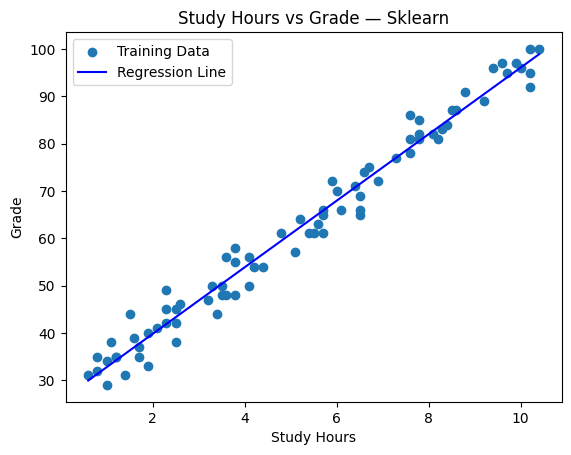

<Figure size 640x480 with 0 Axes>

In [68]:
X_sorted = np.sort(X_train, axis=0)
y_sorted = model.predict(X_sorted)

plt.scatter(X_train, y_train, label="Training Data")
plt.plot(X_sorted, y_sorted, color="blue", label="Regression Line")

plt.xlabel("Study Hours")
plt.ylabel("Grade")
plt.title("Study Hours vs Grade — Sklearn")

plt.legend()
plt.show()
plt.savefig('Study Hours vs Grade-sklearn.png')

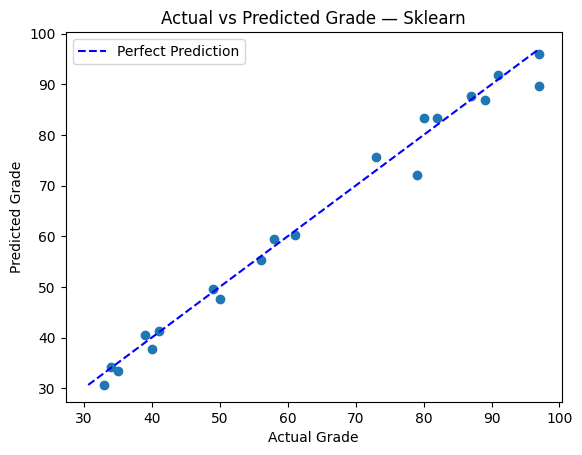

<Figure size 640x480 with 0 Axes>

In [67]:
plt.scatter(y_test, y_pred)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color="blue",
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Grade")
plt.ylabel("Predicted Grade")
plt.title("Actual vs Predicted Grade — Sklearn")

plt.legend()
plt.show()
plt.savefig('Actual vs Predicted Grade-sklearn.png')

In [65]:
print(f"Regression Equation : Grade = {model.coef_[0]:.4f} x study_hours + {model.intercept_:.4f}")

Regression Equation : Grade = 7.0354 x study_hours + 25.7090
